In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

In [2]:
def plot_training_logs(log_file_path, plot_title=None):
    """
    Create plots from training log file
    
    Args:
        log_file_path (str): Path to the .log file
        plot_title (str, optional): Custom title for the plots. If None, uses default titles.
    """
    
    # Read the log file
    try:
        df = pd.read_csv(log_file_path)
    except Exception as e:
        print(f"Error reading file: {e}")
        return
    
    # Add 1 to start from 1 instead of 0
    df['epoch'] = df['epoch'] + 1
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Accuracy vs Step
    ax1.plot(df['step'], df['metric.accuracy.train'], 
             label='Training Accuracy', marker='o', linewidth=2, markersize=4)
    ax1.plot(df['step'], df['metric.accuracy.val'], 
             label='Validation Accuracy', marker='s', linewidth=2, markersize=4)
    
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Accuracy')
    if plot_title:
        ax1.set_title(f'{plot_title} - Training and Validation Accuracy', fontweight='bold')
    else:
        ax1.set_title('Training and Validation Accuracy', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(left=0)
    ax1.set_ylim(0, 1)  # Assuming accuracy is between 0 and 1
    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax1.yaxis.set_major_locator(plt.MultipleLocator(0.10))
    
    # Add epoch information as secondary x-axis
    ax1_twin = ax1.twiny()
    ax1_twin.plot(df['epoch'], df['metric.accuracy.train'], alpha=0)  # Invisible plot to set scale
    ax1_twin.set_xlabel('Epoch')
    ax1_twin.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    # Plot 2: Loss vs Step
    ax2.plot(df['step'], df['loss.global.train'], 
             label='Global Training Loss', marker='o', linewidth=2, markersize=4)
    ax2.plot(df['step'], df['loss.global.val'], 
             label='Global Validation Loss', marker='s', linewidth=2, markersize=4)
    ax2.plot(df['step'], df['loss.crf.train'], 
             label='CRF Training Loss', marker='^', linewidth=2, markersize=4)
    ax2.plot(df['step'], df['loss.crf.val'], 
             label='CRF Validation Loss', marker='v', linewidth=2, markersize=4)
    
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Loss')
    if plot_title:
        ax2.set_title(f'{plot_title} - Training and Validation Losses', fontweight='bold')
    else:
        ax2.set_title('Training and Validation Losses', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(left=0)
    ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    # Add epoch information as secondary x-axis
    ax2_twin = ax2.twiny()
    ax2_twin.plot(df['epoch'], df['loss.global.train'], alpha=0)  # Invisible plot to set scale
    ax2_twin.set_xlabel('Epoch')
    ax2_twin.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n=== Training Summary ===")
    print(f"Total epochs: {df['epoch'].max()}")
    print(f"Best training accuracy: {df['metric.accuracy.train'].max():.4f}")
    print(f"Best validation accuracy: {df['metric.accuracy.val'].max():.4f}")
    print(f"Lowest training loss: {df['loss.global.train'].min():.4f}")
    print(f"Lowest validation loss: {df['loss.global.val'].min():.4f}")
    print(f"Lowest global loss: {min(df['loss.global.train'].min(), df['loss.global.val'].min()):.4f}")

def plot_individual_metrics(log_file_path, plot_title=None):
    """
    Create separate plots for better visualization
    
    Args:
        log_file_path (str): Path to the .log file
        plot_title (str, optional): Custom title for the plots. If None, uses default titles.
    """
    
    # Read the log file
    try:
        df = pd.read_csv(log_file_path)
    except Exception as e:
        print(f"Error reading file: {e}")
        return
    
    # Add 1 to start from 1 instead of 0
    df['epoch'] = df['epoch'] + 1
    # Create individual plots
    plt.figure(figsize=(12, 10))
    
    # Subplot 1: Accuracy
    ax1 = plt.subplot(2, 2, 1)
    plt.plot(df['step'], df['metric.accuracy.train'], 
             label='Training', marker='o', linewidth=2, color='blue')
    plt.plot(df['step'], df['metric.accuracy.val'], 
             label='Validation', marker='s', linewidth=2, color='red')
    plt.xlabel('Step')
    plt.ylabel('Accuracy')
    if plot_title:
        plt.title(f'{plot_title} - Accuracy vs Step', fontweight='bold')
    else:
        plt.title('Accuracy vs Step', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax1.yaxis.set_major_locator(plt.MultipleLocator(0.10))
    
    # Add epoch information as secondary x-axis
    ax1_twin = ax1.twiny()
    ax1_twin.plot(df['epoch'], df['metric.accuracy.train'], alpha=0)
    ax1_twin.set_xlabel('Epoch')
    ax1_twin.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    # Subplot 2: Global Loss
    ax2 = plt.subplot(2, 2, 2)
    plt.plot(df['step'], df['loss.global.train'], 
             label='Training', marker='o', linewidth=2, color='blue')
    plt.plot(df['step'], df['loss.global.val'], 
             label='Validation', marker='s', linewidth=2, color='red')
    plt.xlabel('Step')
    plt.ylabel('Global Loss')
    if plot_title:
        plt.title(f'{plot_title} - Global Loss vs Step', fontweight='bold')
    else:
        plt.title('Global Loss vs Step', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    # Add epoch information as secondary x-axis
    ax2_twin = ax2.twiny()
    ax2_twin.plot(df['epoch'], df['loss.global.train'], alpha=0)
    ax2_twin.set_xlabel('Epoch')
    ax2_twin.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    # Subplot 3: CRF Loss
    ax3 = plt.subplot(2, 2, 3)
    plt.plot(df['step'], df['loss.crf.train'], 
             label='Training', marker='o', linewidth=2, color='blue')
    plt.plot(df['step'], df['loss.crf.val'], 
             label='Validation', marker='s', linewidth=2, color='red')
    plt.xlabel('Step')
    plt.ylabel('CRF Loss')
    if plot_title:
        plt.title(f'{plot_title} - CRF Loss vs Step', fontweight='bold')
    else:
        plt.title('CRF Loss vs Step', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    ax3.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    # Add epoch information as secondary x-axis
    ax3_twin = ax3.twiny()
    ax3_twin.plot(df['epoch'], df['loss.crf.train'], alpha=0)
    ax3_twin.set_xlabel('Epoch')
    ax3_twin.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    # Subplot 4: Learning Rate
    ax4 = plt.subplot(2, 2, 4)
    plt.plot(df['step'], df['lr'], marker='o', linewidth=2, color='green')
    plt.xlabel('Step')
    plt.ylabel('Learning Rate')
    if plot_title:
        plt.title(f'{plot_title} - Learning Rate vs Step', fontweight='bold')
    else:
        plt.title('Learning Rate vs Step', fontweight='bold')
    plt.grid(True, alpha=0.3)
    ax4.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    # Add epoch information as secondary x-axis
    ax4_twin = ax4.twiny()
    ax4_twin.plot(df['epoch'], df['lr'], alpha=0)
    ax4_twin.set_xlabel('Epoch')
    ax4_twin.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    plt.tight_layout()
    plt.show()

Creating combined plots...


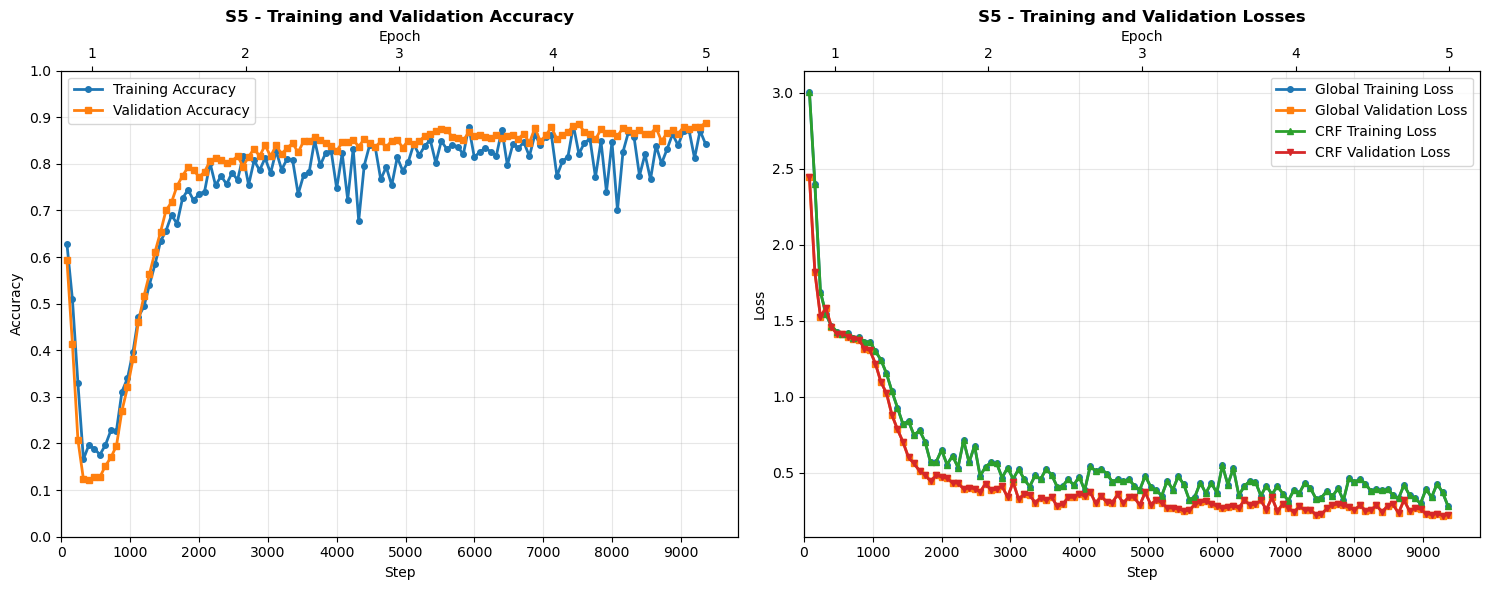


=== Training Summary ===
Total epochs: 5
Best training accuracy: 0.8821
Best validation accuracy: 0.8879
Lowest training loss: 0.2814
Lowest validation loss: 0.2204
Lowest global loss: 0.2204

Creating individual plots...


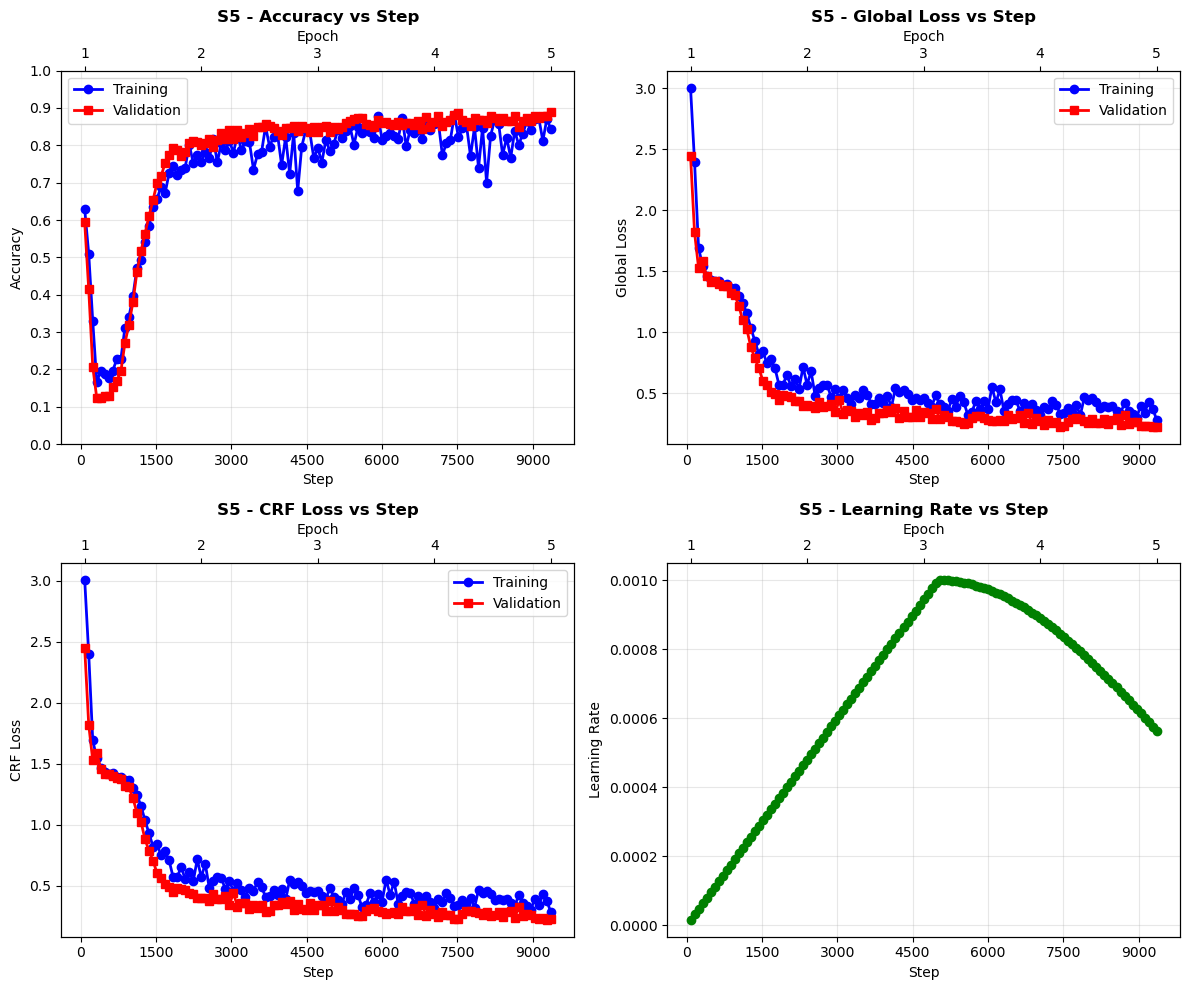

In [3]:
# Replace 'your_log_file.log' with the actual path to your log file

log_file_path = os.getcwd()+"\\out-s5-3.log"
    
print("Creating combined plots...")
plot_training_logs(log_file_path,'S5')
    
print("\nCreating individual plots...")
plot_individual_metrics(log_file_path, 'S5')


In [2]:
def analyze_single_log(log_file_path):
    """
    Analyze a single log file and return summary statistics
    
    Args:
        log_file_path (str): Path to the .log file
        
    Returns:
        dict: Dictionary with summary statistics or None if error
    """
    try:
        df = pd.read_csv(log_file_path)
        
        summary = {
            'file_name': log_file_path,
            'total_epochs': int(df['epoch'].max()+1),
            'best_training_accuracy': df['metric.accuracy.train'].max(),
            'best_validation_accuracy': df['metric.accuracy.val'].max(),
            'lowest_training_loss': df['loss.global.train'].min(),
            'lowest_validation_loss': df['loss.global.val'].min(),
            'lowest_global_loss': min(df['loss.global.train'].min(), df['loss.global.val'].min())
        }
        
        return summary
        
    except Exception as e:
        print(f"Error reading {log_file_path}: {e}")
        return None

def compare_log_files(folder_path):
    """
    Compare all .log files in a folder and find the best performing models
    
    Args:
        folder_path (str): Path to folder containing .log files
    """
    
    # Get all .log files in the folder
    log_files = glob.glob(os.path.join(folder_path, "*.log"))
    
    if not log_files:
        print(f"No .log files found in {folder_path}")
        return
    
    print(f"Found {len(log_files)} log files to analyze...")
    print("=" * 80)
    
    all_summaries = []
    
    # Analyze each log file
    for log_file in log_files:
        file_name = os.path.basename(log_file)
        print(f"\nAnalyzing {file_name}...")
        
        summary = analyze_single_log(log_file)
        if summary:
            summary['file_name'] = file_name  # Store just the filename, not full path
            all_summaries.append(summary)
            
            # Print individual summary
            print(f"  Total epochs: {summary['total_epochs']}")
            print(f"  Best training accuracy: {summary['best_training_accuracy']:.4f}")
            print(f"  Best validation accuracy: {summary['best_validation_accuracy']:.4f}")
            print(f"  Lowest training loss: {summary['lowest_training_loss']:.4f}")
            print(f"  Lowest validation loss: {summary['lowest_validation_loss']:.4f}")
            print(f"  Lowest global loss: {summary['lowest_global_loss']:.4f}")
    
    if not all_summaries:
        print("No valid log files could be analyzed.")
        return
    
    # Find best performing models
    print("\n" + "=" * 80)
    print("COMPARISON RESULTS")
    print("=" * 80)
    
    # Best validation accuracy
    best_val_acc = max(all_summaries, key=lambda x: x['best_validation_accuracy'])
    print(f"\n🏆 HIGHEST VALIDATION ACCURACY:")
    print(f"   File: {best_val_acc['file_name']}")
    print(f"   Validation Accuracy: {best_val_acc['best_validation_accuracy']:.4f}")
    print(f"   Training Accuracy: {best_val_acc['best_training_accuracy']:.4f}")
    
    # Best training accuracy
    best_train_acc = max(all_summaries, key=lambda x: x['best_training_accuracy'])
    print(f"\n🏆 HIGHEST TRAINING ACCURACY:")
    print(f"   File: {best_train_acc['file_name']}")
    print(f"   Training Accuracy: {best_train_acc['best_training_accuracy']:.4f}")
    print(f"   Validation Accuracy: {best_train_acc['best_validation_accuracy']:.4f}")
    
    # Lowest global loss
    best_loss = min(all_summaries, key=lambda x: x['lowest_global_loss'])
    print(f"\n🏆 LOWEST GLOBAL LOSS:")
    print(f"   File: {best_loss['file_name']}")
    print(f"   Lowest Global Loss: {best_loss['lowest_global_loss']:.4f}")
    print(f"   Training Loss: {best_loss['lowest_training_loss']:.4f}")
    print(f"   Validation Loss: {best_loss['lowest_validation_loss']:.4f}")
    
    # Create summary table
    print(f"\n" + "=" * 80)
    print("SUMMARY TABLE")
    print("=" * 80)
    print(f"{'File Name':<25} {'Val Acc':<10} {'Train Acc':<10} {'Global Loss':<12}")
    print("-" * 80)
    
    # Sort by validation accuracy (descending)
    sorted_summaries = sorted(all_summaries, key=lambda x: x['best_validation_accuracy'], reverse=True)
    for summary in sorted_summaries:
        print(f"{summary['file_name']:<25} {summary['best_validation_accuracy']:<10.4f} "
              f"{summary['best_training_accuracy']:<10.4f} {summary['lowest_global_loss']:<12.4f}")


In [3]:
folder_path = os.getcwd()  # Replace with your folder path
print("Comparing all log files in folder...")
compare_log_files(folder_path)

Comparing all log files in folder...
Found 16 log files to analyze...

Analyzing train-1.log...
  Total epochs: 7
  Best training accuracy: 0.8770
  Best validation accuracy: 0.8813
  Lowest training loss: 0.3230
  Lowest validation loss: 0.2753
  Lowest global loss: 0.2753

Analyzing train-1b.log...
  Total epochs: 7
  Best training accuracy: 0.8911
  Best validation accuracy: 0.8922
  Lowest training loss: 0.2635
  Lowest validation loss: 0.2050
  Lowest global loss: 0.2050

Analyzing train-2.log...
  Total epochs: 7
  Best training accuracy: 0.8738
  Best validation accuracy: 0.8735
  Lowest training loss: 0.3248
  Lowest validation loss: 0.2770
  Lowest global loss: 0.2770

Analyzing train-2b.log...
  Total epochs: 7
  Best training accuracy: 0.8923
  Best validation accuracy: 0.8939
  Lowest training loss: 0.2636
  Lowest validation loss: 0.2054
  Lowest global loss: 0.2054

Analyzing train-3.log...
  Total epochs: 7
  Best training accuracy: 0.8795
  Best validation accuracy: 0.8